In [1]:
from pathlib import Path

# Project root = folder containing this notebook's parent folder
PROJECT_ROOT = Path.cwd()

print("Current working directory:")
print(PROJECT_ROOT)

Current working directory:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\notebooks


In [2]:
from pathlib import Path

# Current location: .../Mandrake-Bio/notebooks
CURRENT_DIR = Path.cwd()

# Move one level up to .../Mandrake-Bio
PROJECT_ROOT = CURRENT_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

CSV_PATH = DATA_DIR / "CAS9_STRP1_Spencer_2017_positive.csv"
FASTA_PATH = DATA_DIR / "CAS9_STRP1_WT.fasta"
METADATA_PATH = DATA_DIR / "CAS9_STRP1_metadata.json"
PROVENANCE_PATH = DATA_DIR / "provenance.json"

print("Current directory:")
print(CURRENT_DIR)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nCSV:")
print(CSV_PATH)

print("\nCSV exists:", CSV_PATH.exists())
print("FASTA exists:", FASTA_PATH.exists())
print("Metadata exists:", METADATA_PATH.exists())

Current directory:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\notebooks

Project root:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio

CSV:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\data\CAS9_STRP1_Spencer_2017_positive.csv

CSV exists: True
FASTA exists: True
Metadata exists: True


In [3]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (8117, 4)


,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,A1023D,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.620198,0
1,A1023G,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.424130,0
2,A1023P,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.626792,0
3,A1023S,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.490423,0
4,A1023T,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.543741,0


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']

Data types:
mutant                  str
mutated_sequence        str
DMS_score           float64
DMS_score_bin         int64
dtype: object


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate mutation names:")
print(df["mutant"].duplicated().sum())

print("\nDuplicate sequences:")
print(df["mutated_sequence"].duplicated().sum())

Missing values:
mutant              0
mutated_sequence    0
DMS_score           0
DMS_score_bin       0
dtype: int64

Duplicate mutation names:
0

Duplicate sequences:
0


In [6]:
print(df["DMS_score"].describe())

count    8117.000000
mean       -0.251919
std         0.615909
min        -6.451120
25%        -0.556779
50%        -0.265433
75%         0.034753
max         3.915031
Name: DMS_score, dtype: float64


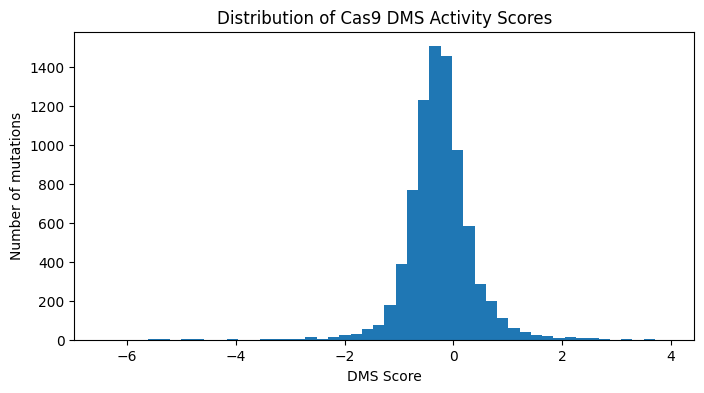

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.hist(df["DMS_score"], bins=50)

plt.xlabel("DMS Score")
plt.ylabel("Number of mutations")
plt.title("Distribution of Cas9 DMS Activity Scores")

plt.show()

In [8]:
def read_fasta(path):
    lines = Path(path).read_text().splitlines()

    header = None
    sequence_parts = []

    for line in lines:
        line = line.strip()

        if not line:
            continue

        if line.startswith(">"):
            header = line[1:]
        else:
            sequence_parts.append(line)

    sequence = "".join(sequence_parts).upper()

    return header, sequence


wt_header, wt_sequence = read_fasta(FASTA_PATH)

print("FASTA header:")
print(wt_header)

print("\nSequence length:", len(wt_sequence))
print("\nFirst 50 amino acids:")
print(wt_sequence[:50])

FASTA header:
CAS9_STRP1_Spencer_2017_positive_WT

Sequence length: 1368

First 50 amino acids:
MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKNLIGA


In [9]:
assert len(wt_sequence) == 1368

valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

invalid = set(wt_sequence) - valid_amino_acids

print("Invalid amino acids:", invalid)

assert len(invalid) == 0

print("✓ WT Cas9 sequence is valid")

Invalid amino acids: set()
✓ WT Cas9 sequence is valid


In [10]:
import re

mutation_pattern = re.compile(
    r"^(?P<wt>[A-Z])(?P<position>\d+)(?P<mut>[A-Z])$"
)

def parse_mutation(mutation):
    match = mutation_pattern.match(mutation)

    if match is None:
        raise ValueError(f"Invalid mutation format: {mutation}")

    return {
        "wt_residue": match.group("wt"),
        "position": int(match.group("position")),
        "mutant_residue": match.group("mut")
    }


parsed_mutations = df["mutant"].apply(parse_mutation)

mutation_features = pd.DataFrame(
    parsed_mutations.tolist(),
    index=df.index
)

df = pd.concat(
    [df, mutation_features],
    axis=1
)

display(df.head())

,mutant,mutated_sequence,DMS_score,DMS_score_bin,wt_residue,position,mutant_residue
0,A1023D,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.620198,0,A,1023,D
1,A1023G,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.424130,0,A,1023,G
2,A1023P,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.626792,0,A,1023,P
3,A1023S,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.490423,0,A,1023,S
4,A1023T,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.543741,0,A,1023,T


In [12]:
df["wt_from_fasta"] = df["position"].apply(
    lambda position: wt_sequence[position - 1]
)

mismatch = df[
    df["wt_residue"] != df["wt_from_fasta"]
]

print("Number of WT residue mismatches:", len(mismatch))

display(
    mismatch[
        [
            "mutant",
            "wt_residue",
            "position",
            "wt_from_fasta"
        ]
    ].head()
)

Number of WT residue mismatches: 0


,mutant,wt_residue,position,wt_from_fasta


In [13]:
assert len(mismatch) == 0

print("✓ All mutation annotations match the WT Cas9 sequence")

✓ All mutation annotations match the WT Cas9 sequence


In [14]:
def count_sequence_differences(seq1, seq2):
    return sum(
        a != b
        for a, b in zip(seq1, seq2)
    )


df["n_changes"] = df["mutated_sequence"].apply(
    lambda seq: count_sequence_differences(
        wt_sequence,
        seq
    )
)

print(df["n_changes"].value_counts().sort_index())

n_changes
1    8117
Name: count, dtype: int64


In [15]:
assert (df["n_changes"] == 1).all()

print("✓ Every mutant differs from WT at exactly one position")

✓ Every mutant differs from WT at exactly one position


In [16]:
def validate_mutation_sequence(row):
    position = row["position"]
    mutant_aa = row["mutant_residue"]
    mutant_sequence = row["mutated_sequence"]

    # Check that the mutant sequence contains
    # the expected amino acid at the expected position.
    return mutant_sequence[position - 1] == mutant_aa


df["mutation_sequence_valid"] = df.apply(
    validate_mutation_sequence,
    axis=1
)

print(
    "Invalid mutation/sequence pairs:",
    (~df["mutation_sequence_valid"]).sum()
)

assert df["mutation_sequence_valid"].all()

print("✓ Mutation labels agree with mutant sequences")

Invalid mutation/sequence pairs: 0
✓ Mutation labels agree with mutant sequences


In [17]:
df = df.drop(
    columns=[
        "wt_from_fasta",
        "n_changes",
        "mutation_sequence_valid"
    ]
)

print(df.columns.tolist())

['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin', 'wt_residue', 'position', 'mutant_residue']


In [18]:
print("Unique mutation positions:", df["position"].nunique())

print("\nMutations per position:")
print(df["position"].value_counts().describe())

Unique mutation positions: 1368

Mutations per position:
count    1368.000000
mean        5.933480
std         0.743146
min         4.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         7.000000
Name: count, dtype: float64


In [19]:
print(
    df.groupby("position")
      .size()
      .sort_values()
      .head(20)
)

position
1366    4
1354    4
417     4
453     4
469     4
582     4
653     4
236     4
660     4
661     4
729     4
204     4
205     4
792     4
773     4
777     4
765     4
864     4
845     4
55      4
dtype: int64


# Train / Validation / Test Split

We use two evaluation settings.

### Primary split: position-held-out

The split is performed by residue position. Therefore, no mutation from a
test position can appear in the training set.

This evaluates whether the model can generalize to mutations at previously
unseen positions in Cas9.

### Secondary split: random mutation split

Individual mutations are randomly divided into train/validation/test sets.
Different mutations from the same position may appear in different splits.

This measures interpolation to new substitutions at positions that may already
be represented during training.

The position-held-out split is our primary evaluation because it provides a
more stringent test of position-level generalization.

In [20]:
from sklearn.model_selection import GroupShuffleSplit

In [22]:
SEED = 42

groups = df["position"].to_numpy()

# ---------------------------------------------------
# First split:
# 80% of positions -> training
# 20% -> temporary pool
# ---------------------------------------------------

splitter_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_idx, temp_idx = next(
    splitter_1.split(
        df,
        groups=groups
    )
)

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()


# ---------------------------------------------------
# Second split:
# Split the temporary 20% equally into:
# 10% validation
# 10% test
# ---------------------------------------------------

splitter_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

temp_groups = temp_df["position"].to_numpy()

val_idx, test_idx = next(
    splitter_2.split(
        temp_df,
        groups=temp_groups
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

In [23]:
print("TRAIN")
print("Mutations:", len(train_df))
print("Positions:", train_df["position"].nunique())

print("\nVALIDATION")
print("Mutations:", len(val_df))
print("Positions:", val_df["position"].nunique())

print("\nTEST")
print("Mutations:", len(test_df))
print("Positions:", test_df["position"].nunique())

TRAIN
Mutations: 6490
Positions: 1094

VALIDATION
Mutations: 810
Positions: 137

TEST
Mutations: 817
Positions: 137


In [24]:
train_positions = set(train_df["position"])
val_positions = set(val_df["position"])
test_positions = set(test_df["position"])

print(
    "Train ∩ Validation:",
    len(train_positions & val_positions)
)

print(
    "Train ∩ Test:",
    len(train_positions & test_positions)
)

print(
    "Validation ∩ Test:",
    len(val_positions & test_positions)
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [25]:
assert train_positions.isdisjoint(val_positions)
assert train_positions.isdisjoint(test_positions)
assert val_positions.isdisjoint(test_positions)

print("✓ No residue position appears in multiple splits")

✓ No residue position appears in multiple splits


In [26]:
train_mutations = set(train_df["mutant"])
val_mutations = set(val_df["mutant"])
test_mutations = set(test_df["mutant"])

assert train_mutations.isdisjoint(val_mutations)
assert train_mutations.isdisjoint(test_mutations)
assert val_mutations.isdisjoint(test_mutations)

print("✓ No mutation appears in multiple splits")

✓ No mutation appears in multiple splits


In [27]:
total_rows = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("Total rows:", total_rows)
print("Original rows:", len(df))

assert total_rows == len(df)

print("✓ Every mutation belongs to exactly one split")

Total rows: 8117
Original rows: 8117
✓ Every mutation belongs to exactly one split


In [28]:
print("TRAIN")
print(train_df["DMS_score"].describe())

print("\nVALIDATION")
print(val_df["DMS_score"].describe())

print("\nTEST")
print(test_df["DMS_score"].describe())

TRAIN
count    6490.000000
mean       -0.255413
std         0.622418
min        -6.451120
25%        -0.558396
50%        -0.267671
75%         0.035323
max         3.542348
Name: DMS_score, dtype: float64

VALIDATION
count    810.000000
mean      -0.224252
std        0.592612
min       -2.746326
25%       -0.542635
50%       -0.241308
75%        0.036792
max        3.547413
Name: DMS_score, dtype: float64

TEST
count    817.000000
mean      -0.251594
std        0.585867
min       -5.549185
25%       -0.556779
50%       -0.272815
75%        0.019711
max        3.915031
Name: DMS_score, dtype: float64


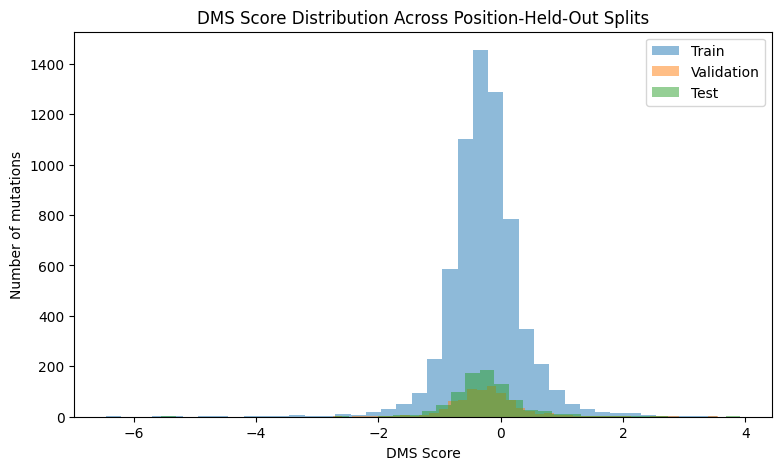

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    train_df["DMS_score"],
    bins=40,
    alpha=0.5,
    label="Train"
)

plt.hist(
    val_df["DMS_score"],
    bins=40,
    alpha=0.5,
    label="Validation"
)

plt.hist(
    test_df["DMS_score"],
    bins=40,
    alpha=0.5,
    label="Test"
)

plt.xlabel("DMS Score")
plt.ylabel("Number of mutations")
plt.title("DMS Score Distribution Across Position-Held-Out Splits")
plt.legend()

plt.show()